In [1]:
import os

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [2]:
import torch
import torch.nn as nn

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

class Generator(nn.Module):
    def __init__(self, z_dim=100, img_dim=784):
        super(Generator, self).__init__()
        self.gen = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),

            nn.Linear(1024, img_dim),
            nn.Tanh()
        )
    def forward(self, x):
        return self.gen(x)

In [3]:
class Discriminator(nn.Module):
    def __init__(self, img_dim=784):
        super(Discriminator, self).__init__()

        self.disc = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.disc(x)

In [1]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Подменяем сломанные ссылки на стабильное зеркало от Google
torchvision.datasets.MNIST.mirrors = [
    'https://storage.googleapis.com/cvdf-datasets/mnist/'
]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset_tv = torchvision.datasets.MNIST(root="../data/MNIST/", train=True, transform=transform, download=True)

In [5]:
batch_size = 64
dataloader = DataLoader(dataset_tv, batch_size=batch_size, shuffle=True)

In [6]:
# Импортируем метрику
from torchmetrics.image.fid import FrechetInceptionDistance

# 1. Создаем "Оценщика"
# feature=64 означает, что мы берем легкую версию сети, чтобы считалось быстрее
fid_metric = FrechetInceptionDistance(feature=64).to(device)

# --- ВНУТРИ ТВОЕГО ЦИКЛА ОБУЧЕНИЯ (например, каждые 10 эпох) ---
def calculate_fid(real_images, fake_images):
    # FID ОЧЕНЬ капризен к формату данных.
    # Он требует картинки в формате байтов (от 0 до 255) типа torch.uint8
    # И размерность должна быть [B, C, H, W]

    # 1. Возвращаем картинки из плоского вида (784) в квадратный (1, 28, 28)
    real_imgs_2d = real_images.reshape(-1, 1, 28, 28)
    fake_imgs_2d = fake_images.reshape(-1, 1, 28, 28)

    # 2. Если картинки черно-белые, копируем канал 3 раза, чтобы притвориться RGB
    real_imgs_rgb = real_imgs_2d.repeat(1, 3, 1, 1)
    fake_imgs_rgb = fake_imgs_2d.repeat(1, 3, 1, 1)

    # 3. Переводим из диапазона [-1, 1] в [0, 255]
    real_imgs_uint8 = ((real_imgs_rgb + 1) / 2 * 255).byte()
    fake_imgs_uint8 = ((fake_imgs_rgb + 1) / 2 * 255).byte()

    # 4. Скармливаем Оценщику (real=True для настоящих, real=False для фейков)
    fid_metric.update(real_imgs_uint8, real=True)
    fid_metric.update(fake_imgs_uint8, real=False)

    # 5. Получаем финальную оценку (чем меньше, тем лучше!)
    fid_score = fid_metric.compute()

    # Сбрасываем метрику для следующих замеров
    fid_metric.reset()

    return fid_score.item()

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to C:\Users\egorm/.cache\torch\hub\checkpoints\weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:10<00:00, 8.89MB/s]


In [13]:
import torch.optim as optim

gen = Generator().to(device)
disc = Discriminator().to(device)

criterion = nn.BCELoss()

lr = 0.0002
opt_gen = optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))

In [14]:
epochs = 10
batch_size = 64

gen.train()
disc.train()

loss_gen = torch.tensor(0.0)

fid_scores = []
gen_losses = []
disc_losses = []

for epoch in range(epochs):
    # Теперь мы идем по реальному датасету!
    for batch_idx, (real_images, _) in enumerate(dataloader):

        # 1. Сплющиваем картинки и ОТПРАВЛЯЕМ НА DEVICE
        real_images = real_images.view(real_images.size(0), -1).to(device)

        # --- ОБУЧЕНИЕ ДИСКРИМИНАТОРА ---
        disc_real_output = disc(real_images)

        # Сглаживание меток (Label Smoothing) - возвращаем наш трюк с 0.9!
        labels_real = (torch.ones_like(disc_real_output) * 0.9).to(device)
        loss_disc_real = criterion(disc_real_output, labels_real)

        # Шум тоже на device
        noise = torch.randn(real_images.size(0), 100).to(device)
        fake_images = gen(noise)
        disc_fake_output = disc(fake_images.detach())

        labels_fake = torch.zeros_like(disc_fake_output).to(device)
        loss_disc_fake = criterion(disc_fake_output, labels_fake)

        loss_disc = (loss_disc_fake + loss_disc_real) / 2
        opt_disc.zero_grad()
        loss_disc.backward()
        opt_disc.step()

        # --- ОБУЧЕНИЕ ГЕНЕРАТОРА ---
        if batch_idx % 100 != 0:
            output = disc(fake_images)
            labels_gen = torch.ones_like(output).to(device) # Метки на device
            loss_gen = criterion(output, labels_gen)

            opt_gen.zero_grad()
            loss_gen.backward()
            opt_gen.step()

        # --- ЛОГИРОВАНИЕ ---
        if batch_idx % 100 == 0:
            gen_losses.append(loss_gen.item())
            disc_losses.append(loss_disc.item())
            print(f"Эпоха [{epoch}/{epochs}] | Батч [{batch_idx}/{len(dataloader)}] | Loss D: {loss_disc.item():.4f} | Loss G: {loss_gen.item():.4f}")

    gen.eval()

    with torch.no_grad():
        # 2. Генерируем 64 фейковые картинки
        test_noise = torch.randn(64, 100).to(device)
        fake_images_fid = gen(test_noise)

        # 3. В качестве real_images мы просто берем переменную real_images,
        # которая осталась от последнего шага внутреннего цикла (там как раз лежат реальные цифры)

        # 4. Считаем FID
        fid_score = calculate_fid(real_images, fake_images_fid)
        fid_scores.append(fid_score)
        print(f"--- Эпоха [{epoch}/{epochs}] завершена | FID Score: {fid_score:.2f} ---")

    # 5. Возвращаем генератор в режим обучения для следующей эпохи!
    gen.train()

Эпоха [0/10] | Батч [0/938] | Loss D: 0.6595 | Loss G: 0.0000
Эпоха [0/10] | Батч [100/938] | Loss D: 0.6203 | Loss G: 1.2590
Эпоха [0/10] | Батч [200/938] | Loss D: 0.6847 | Loss G: 0.8851
Эпоха [0/10] | Батч [300/938] | Loss D: 0.6563 | Loss G: 0.9144
Эпоха [0/10] | Батч [400/938] | Loss D: 0.5621 | Loss G: 1.4505
Эпоха [0/10] | Батч [500/938] | Loss D: 0.5320 | Loss G: 1.2148
Эпоха [0/10] | Батч [600/938] | Loss D: 0.5784 | Loss G: 1.3359
Эпоха [0/10] | Батч [700/938] | Loss D: 0.5384 | Loss G: 1.6447
Эпоха [0/10] | Батч [800/938] | Loss D: 0.5866 | Loss G: 1.1168
Эпоха [0/10] | Батч [900/938] | Loss D: 0.5873 | Loss G: 1.0815
--- Эпоха [0/10] завершена | FID Score: 3.93 ---
Эпоха [1/10] | Батч [0/938] | Loss D: 0.7522 | Loss G: 2.2717
Эпоха [1/10] | Батч [100/938] | Loss D: 0.5424 | Loss G: 1.3190
Эпоха [1/10] | Батч [200/938] | Loss D: 0.5948 | Loss G: 1.5896
Эпоха [1/10] | Батч [300/938] | Loss D: 0.6205 | Loss G: 1.4405
Эпоха [1/10] | Батч [400/938] | Loss D: 0.5344 | Loss G: 1.

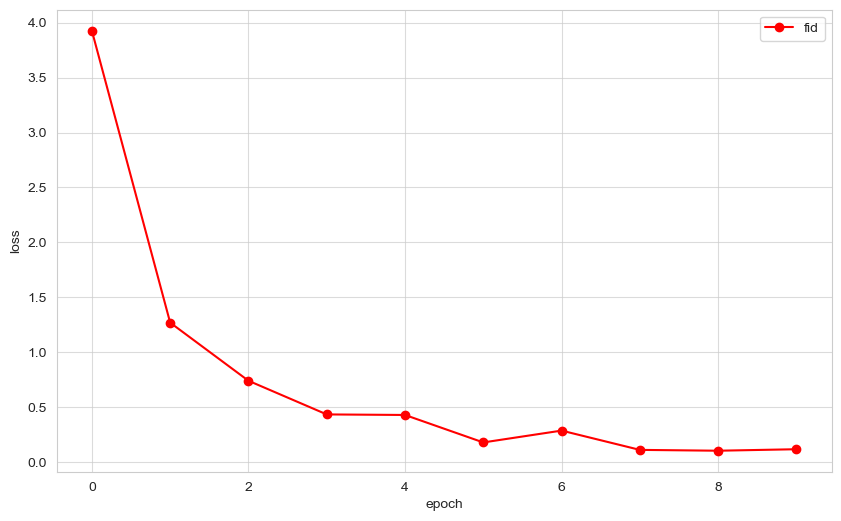

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(fid_scores, label='fid', marker='o', color='r')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(True, linestyle='-', alpha=0.7)
plt.legend()
plt.show()

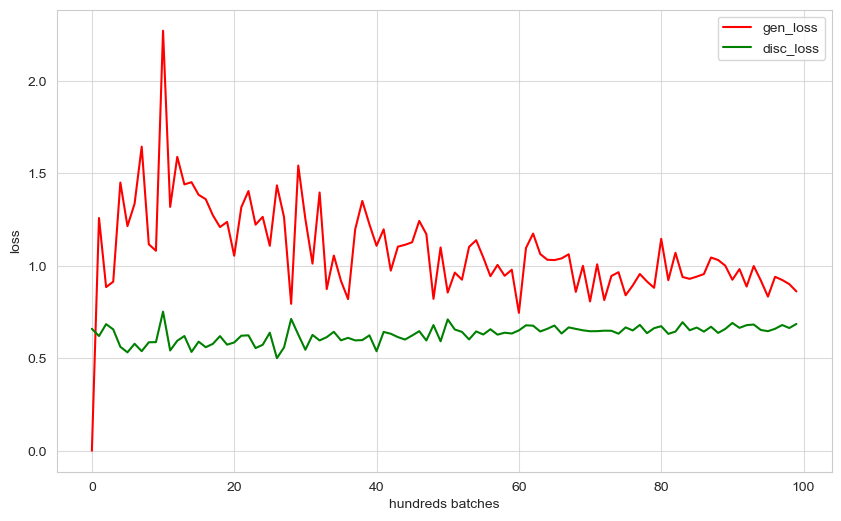

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(gen_losses, label='gen_loss', color='r')
plt.plot(disc_losses, label='disc_loss', color='g')
plt.xlabel("hundreds batches")
plt.ylabel("loss")
plt.grid(True, linestyle='-', alpha=0.7)
plt.legend()
plt.show()

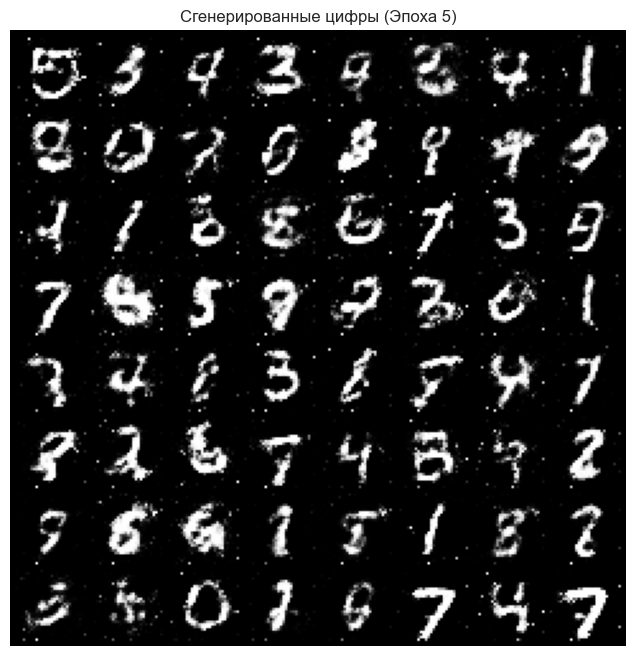

In [12]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

gen.eval()

with torch.no_grad():
    test_noise = torch.randn(64, 100).to(device)

    generated_images = gen(test_noise)

    generated_images = generated_images.view(-1, 1, 28, 28)

    generated_images = (generated_images + 1) / 2

    grid = vutils.make_grid(generated_images, nrow=8, padding=2, normalize=False)

    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.title("Сгенерированные цифры (Эпоха 5)")
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.show()